In [4]:
pip install arch

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import norm
from scipy.stats import genextreme as gev
from scipy.stats import genpareto
from arch import arch_model
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

In [6]:
df = pd.read_csv('MU.csv')

In [7]:
df

,Date,MU
0,2000-01-03,37.030437
1,2000-01-04,35.597984
2,2000-01-05,35.476067
3,2000-01-06,36.085625
4,2000-01-07,34.378876
...,...,...
6650,2026-06-12,981.609985
6651,2026-06-15,1087.989990
6652,2026-06-16,1020.760010
6653,2026-06-17,1043.189941


In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

In [9]:
df = df.sort_index()

In [10]:
df.index.duplicated().sum()

np.int64(0)

In [11]:
df.isna().sum()

,0
MU,0


In [12]:
returns = np.log(df['MU']/df['MU'].shift(1))

In [13]:
returns = returns.dropna()

/tmp/ipykernel_2298/2133435646.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_returns = returns.resample('M').sum()


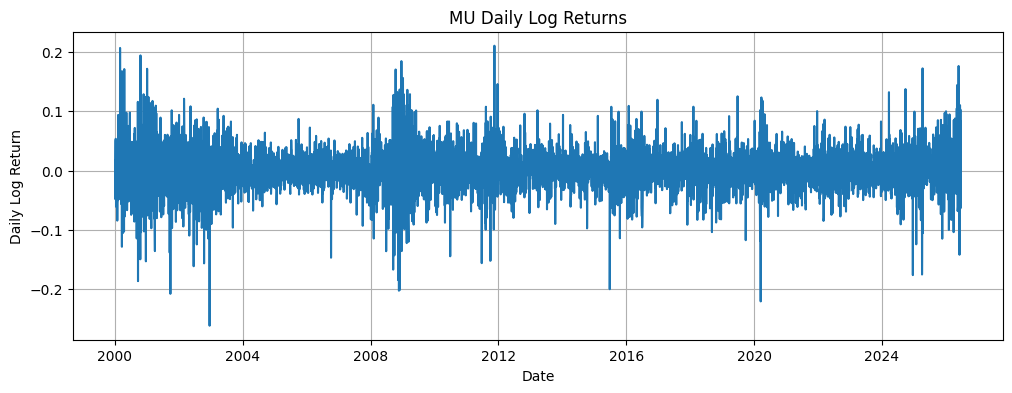

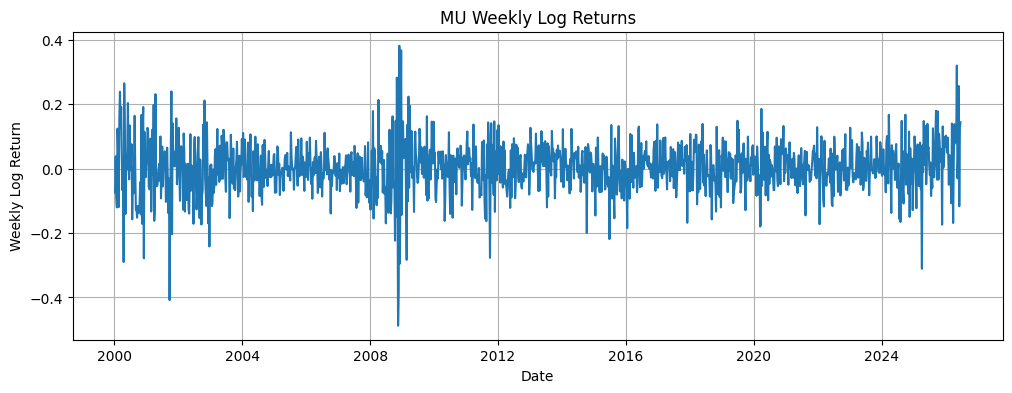

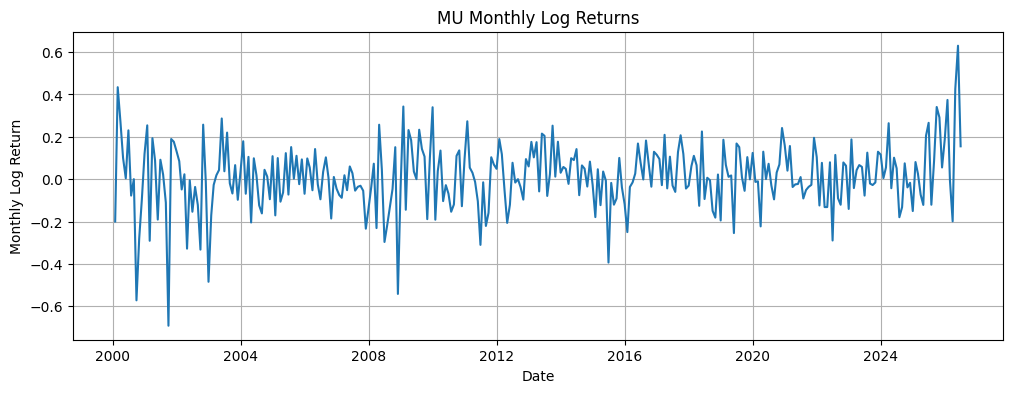

In [14]:
weekly_returns = returns.resample('W').sum()
monthly_returns = returns.resample('M').sum()

# Daily Returns
plt.figure(figsize=(12,4))

plt.plot(returns.index, returns)

plt.title('MU Daily Log Returns')
plt.xlabel('Date')
plt.ylabel('Daily Log Return')

plt.grid(True)
plt.show()

# Weekly Returns
plt.figure(figsize=(12,4))

plt.plot(weekly_returns.index, weekly_returns)

plt.title('MU Weekly Log Returns')
plt.xlabel('Date')
plt.ylabel('Weekly Log Return')

plt.grid(True)
plt.show()

# Monthly Returns
plt.figure(figsize=(12,4))

plt.plot(monthly_returns.index, monthly_returns)

plt.title('MU Monthly Log Returns')
plt.xlabel('Date')
plt.ylabel('Monthly Log Return')

plt.grid(True)
plt.show()

In [15]:
from scipy.stats import skew, kurtosis

summary_stats = pd.concat(
    [
        returns.describe(),
        weekly_returns.describe(),
        monthly_returns.describe()
    ],
    axis=1
)

summary_stats.columns = ['Daily', 'Weekly', 'Monthly']

extra_stats = pd.DataFrame({
"Daily":[skew(returns),kurtosis(returns)],
"Weekly":[skew(weekly_returns),kurtosis(weekly_returns)],
"Monthly":[skew(monthly_returns),kurtosis(monthly_returns)]
},
index=["Skewness","Kurtosis"])

summary_stats = pd.concat([summary_stats, extra_stats])

summary_stats

,Daily,Weekly,Monthly
count,6654.000000,1381.000000,318.000000
mean,0.000514,0.002478,0.010760
std,0.035593,0.077648,0.155633
min,-0.261913,-0.488022,-0.691819
25%,-0.017713,-0.036576,-0.073232
50%,0.000043,0.001998,0.010637
75%,0.019051,0.047026,0.102963
max,0.210611,0.382019,0.629974
Skewness,-0.140542,-0.303835,-0.399927
Kurtosis,4.160239,3.604941,2.511286


In [16]:
# Non Parametric VaR (quick-view)
pd.DataFrame({
    "Daily": returns.quantile([0.01,0.05,0.95,0.99]),
    "Weekly": weekly_returns.quantile([0.01,0.05,0.95,0.99]),
    "Monthly": monthly_returns.quantile([0.01,0.05,0.95,0.99])
})

,Daily,Weekly,Monthly
0.01,-0.097262,-0.187884,-0.468986
0.05,-0.054018,-0.126294,-0.224052
0.95,0.055770,0.123603,0.252844
0.99,0.100107,0.195928,0.368773


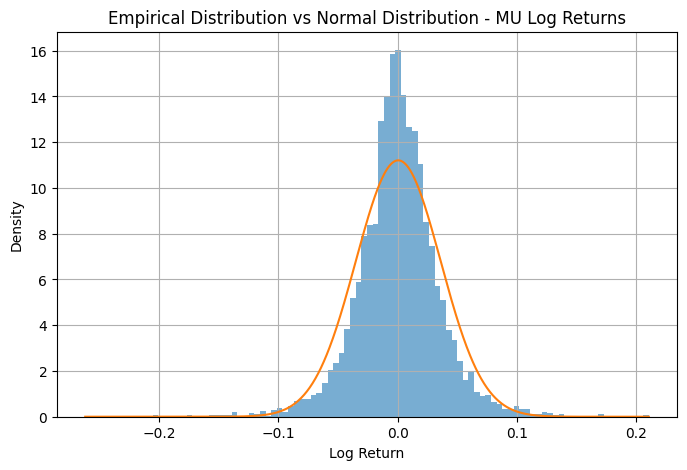

In [17]:
plt.figure(figsize=(8,5))

plt.hist(returns, bins=100, density=True, alpha=0.6)

mu = returns.mean()
sigma = returns.std()

x = np.linspace(returns.min(), returns.max(), 1000)

normal = stats.norm.pdf(x, mu, sigma)

plt.plot(x, normal)

plt.title('Empirical Distribution vs Normal Distribution - MU Log Returns')
plt.xlabel('Log Return')
plt.ylabel('Density')

plt.grid(True)
plt.show()

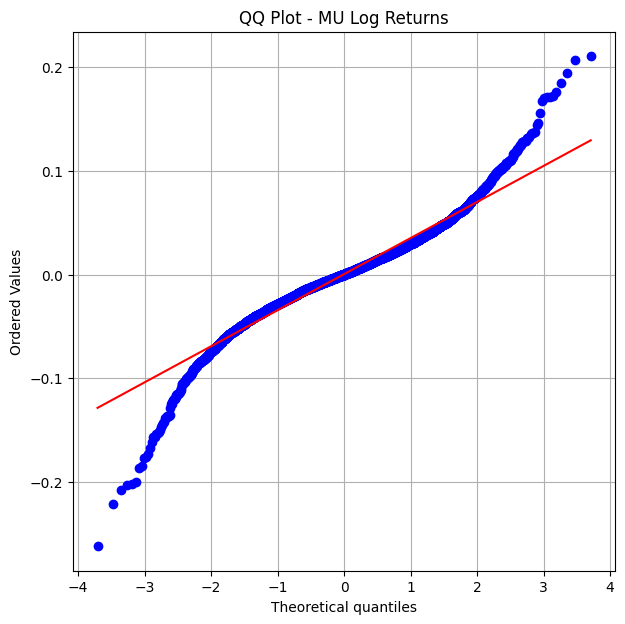

In [18]:
plt.figure(figsize=(7,7))

stats.probplot(returns, dist="norm", plot=plt)

plt.title('QQ Plot - MU Log Returns')
plt.grid(True)

plt.show()

In [19]:
daily_vol = returns.std()

annual_vol = daily_vol * np.sqrt(252)

print(f"Daily Volatility: {daily_vol:.4%}")
print(f"Annualized Volatility: {annual_vol:.4%}")

Daily Volatility: 3.5593%
Annualized Volatility: 56.5024%


In [20]:
daily_window = 21
weekly_window = 4
monthly_window = 12

rolling_daily_vol = returns.rolling(daily_window).std() * np.sqrt(252)
rolling_weekly_vol = weekly_returns.rolling(weekly_window).std() * np.sqrt(52)
rolling_monthly_vol = monthly_returns.rolling(monthly_window).std() * np.sqrt(12)

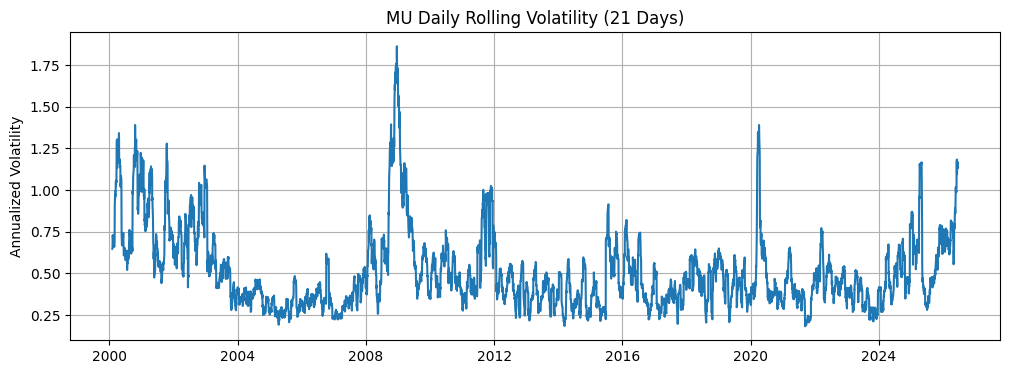

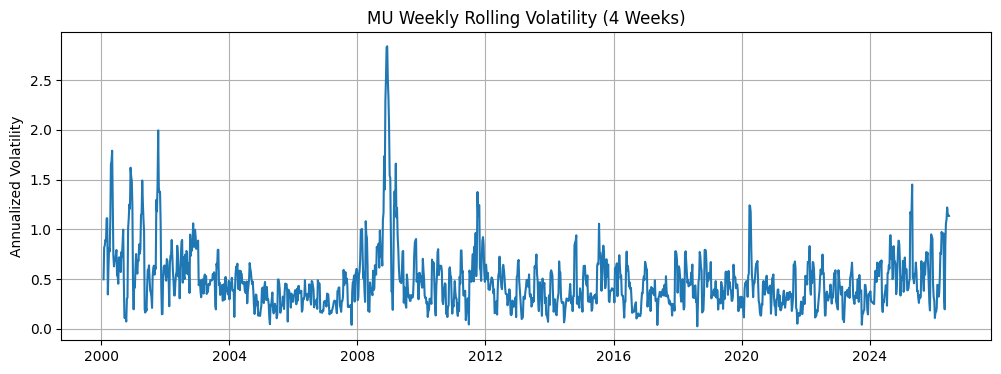

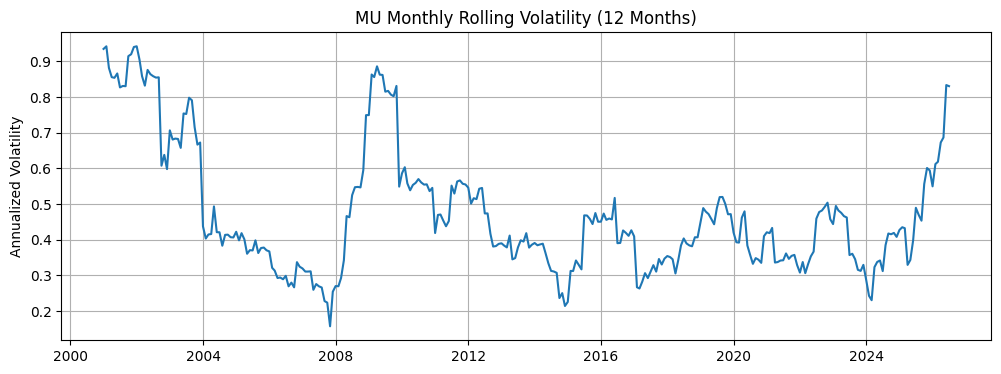

In [21]:
# Daily rolling volatility
plt.figure(figsize=(12,4))

plt.plot(rolling_daily_vol)

plt.title("MU Daily Rolling Volatility (21 Days)")
plt.ylabel("Annualized Volatility")

plt.grid(True)
plt.show()


# Weekly rolling volatility
plt.figure(figsize=(12,4))

plt.plot(rolling_weekly_vol)

plt.title("MU Weekly Rolling Volatility (4 Weeks)")
plt.ylabel("Annualized Volatility")

plt.grid(True)
plt.show()


# Monthly rolling volatility
plt.figure(figsize=(12,4))

plt.plot(rolling_monthly_vol)

plt.title("MU Monthly Rolling Volatility (12 Months)")
plt.ylabel("Annualized Volatility")

plt.grid(True)
plt.show()

/tmp/ipykernel_2298/1788657766.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  block_maxima = losses.resample('M').max().dropna()


--- GEV PARAMETERS ---
Shape parameter (c): -0.2137 (If c < 0, Fréchet type)
Location (mu): 0.0453
Scale (sigma): 0.0223



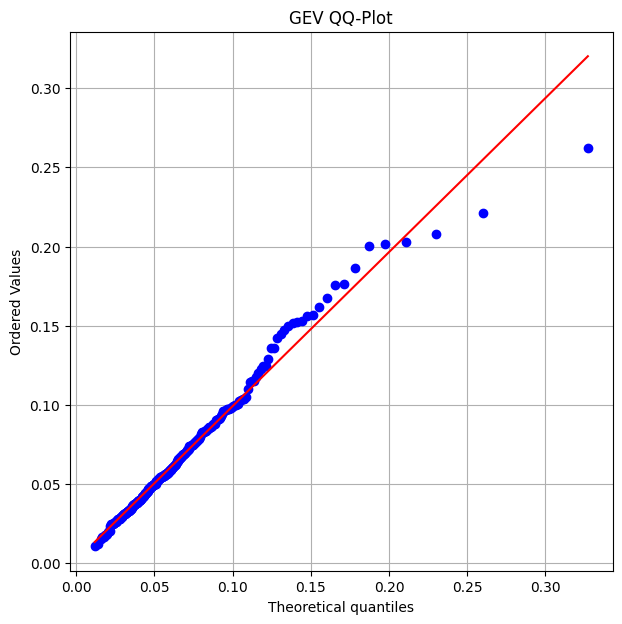

In [22]:
losses = -returns

# Block Maxima approach
block_maxima = losses.resample('M').max().dropna()

# GEV fit
c_gev, loc_gev, scale_gev = stats.genextreme.fit(block_maxima)

print("--- GEV PARAMETERS ---")
print(f"Shape parameter (c): {c_gev:.4f} (If c < 0, Fréchet type)")
print(f"Location (mu): {loc_gev:.4f}")
print(f"Scale (sigma): {scale_gev:.4f}\n")

# GEV QQ-Plot
plt.figure(figsize=(7, 7))

stats.probplot(block_maxima, dist=stats.genextreme, sparams=(c_gev, loc_gev, scale_gev), plot=plt)

plt.title('GEV QQ-Plot')
plt.grid(True)
plt.show()

$$\hat{e}_i = \left(1 + \hat{\xi}\left(\frac{M_n^{(i)} - \hat{\mu}}{\hat{\sigma}}\right)\right)^{-1/\hat{\xi}}$$

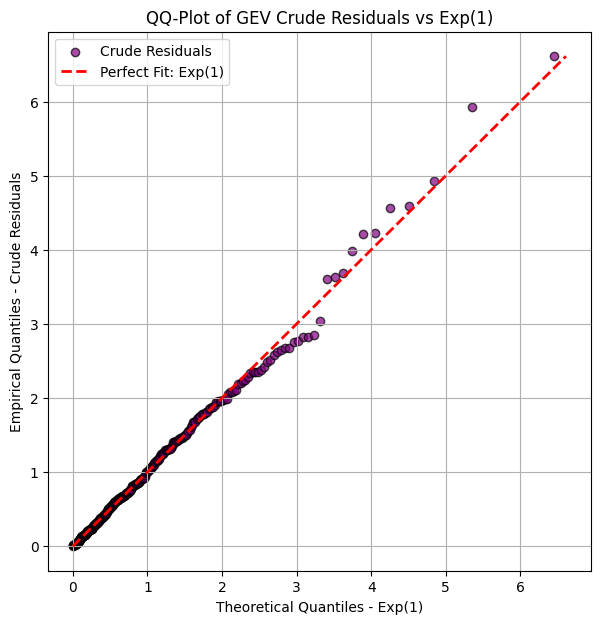

In [23]:
gev_argument = 1 - c_gev * ((block_maxima - loc_gev) / scale_gev)

gev_argument = np.maximum(gev_argument, 1e-10)

crude_residuals = gev_argument ** (1 / c_gev)

sorted_residuals = np.sort(crude_residuals)
n_res = len(sorted_residuals)


empirical_probs_res = (np.arange(1, n_res + 1) - 0.5) / n_res
theoretical_exp_quantiles = stats.expon.ppf(empirical_probs_res, scale=1)

plt.figure(figsize=(7, 7))

plt.scatter(theoretical_exp_quantiles, sorted_residuals, color='purple', alpha=0.7, edgecolors='k', label='Crude Residuals')

max_val_res = max(max(sorted_residuals), max(theoretical_exp_quantiles))
plt.plot([0, max_val_res], [0, max_val_res], color='red', linestyle='--', linewidth=2, label='Perfect Fit: Exp(1)')

plt.title('QQ-Plot of GEV Crude Residuals vs Exp(1)')
plt.xlabel('Theoretical Quantiles - Exp(1)')
plt.ylabel('Empirical Quantiles - Crude Residuals')
plt.legend()
plt.grid(True)
plt.show()

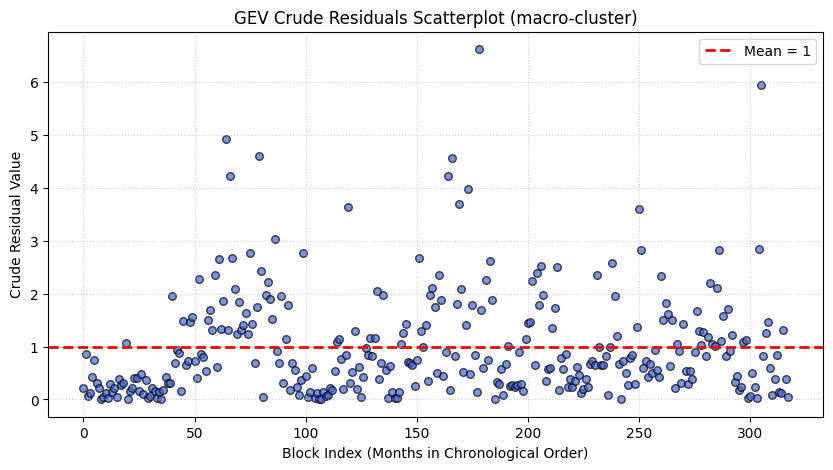

In [24]:
gev_cdf = stats.genextreme.cdf(block_maxima, c_gev, loc_gev, scale_gev)

gev_cdf = np.clip(gev_cdf, 1e-10, 1 - 1e-10)

gev_residuals = -np.log(gev_cdf)

plt.figure(figsize=(10, 5))
plt.scatter(range(len(gev_residuals)), gev_residuals, color='royalblue', alpha=0.7, edgecolors='k', s=30)

plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Mean = 1')

plt.title('GEV Crude Residuals Scatterplot (macro-cluster)')
plt.xlabel('Block Index (Months in Chronological Order)')
plt.ylabel('Crude Residual Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

ê(u) = (1 / nᵤ) Σᵢ₌₁ⁿᵤ (x⁽ⁱ⁾ − u)

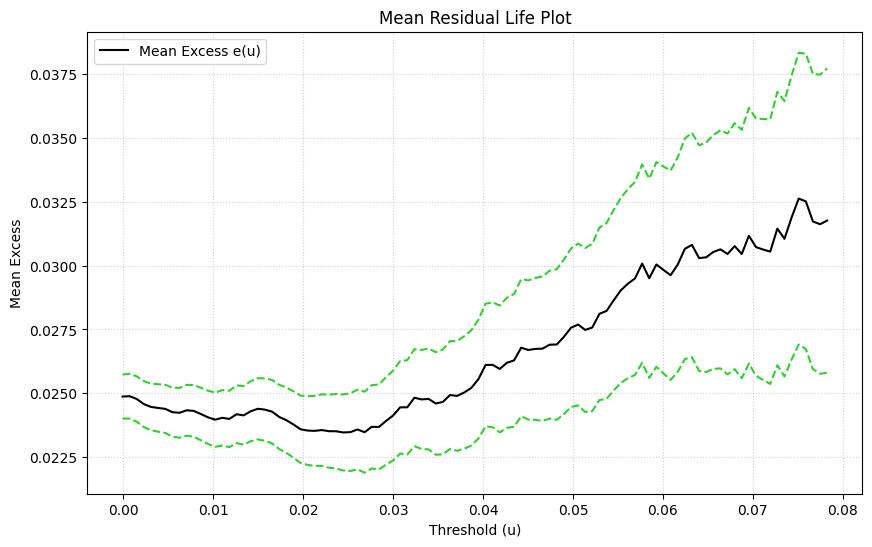

In [25]:
thresholds = np.linspace(losses.quantile(0.50), losses.quantile(0.98), 100)

mean_excess = []
confidence_intervals = []

for u in thresholds:
    exceedances = losses[losses > u] - u
    n_u = len(exceedances)

    if n_u > 5:
        mean_e = exceedances.mean()
        std_e = exceedances.std()

        se_e = std_e / np.sqrt(n_u)

        mean_excess.append(mean_e)
        confidence_intervals.append(1.96 * se_e)
    else:
        thresholds = thresholds[:len(mean_excess)]
        break

mean_excess = np.array(mean_excess)
confidence_intervals = np.array(confidence_intervals)

plt.figure(figsize=(10, 6))

plt.plot(thresholds, mean_excess, color='black', label='Mean Excess e(u)')

plt.plot(thresholds, mean_excess + confidence_intervals, color='limegreen', linestyle='--')
plt.plot(thresholds, mean_excess - confidence_intervals, color='limegreen', linestyle='--')

plt.title('Mean Residual Life Plot')
plt.xlabel('Threshold (u)')
plt.ylabel('Mean Excess')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

e(u)=E[X−u∣X>u]

In [26]:
u_gpd = 0.04

exceedances = losses[losses > u_gpd] - u_gpd

len(exceedances)

613

In [27]:
c, loc, scale = genpareto.fit(
    exceedances,
    floc=0
)

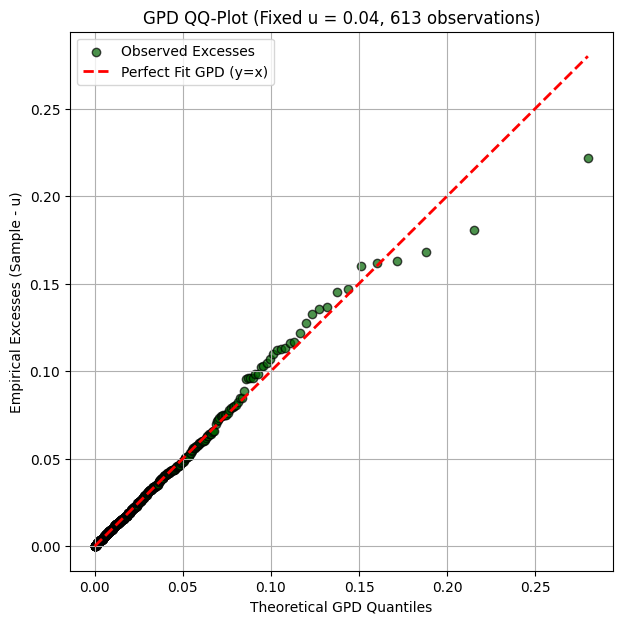

In [28]:
sorted_exceedances = np.sort(exceedances)
n_gpd = len(sorted_exceedances)

# empirical probability
empirical_probs_gpd = (np.arange(1, n_gpd + 1) - 0.5) / n_gpd

theoretical_quantiles_gpd = genpareto.ppf(empirical_probs_gpd, c, loc, scale)

plt.figure(figsize=(7, 7))

plt.scatter(theoretical_quantiles_gpd, sorted_exceedances, color='darkgreen', alpha=0.7, edgecolors='k', label='Observed Excesses')

max_val_gpd = max(max(sorted_exceedances), max(theoretical_quantiles_gpd))
plt.plot([0, max_val_gpd], [0, max_val_gpd], color='red', linestyle='--', linewidth=2, label='Perfect Fit GPD (y=x)')

plt.title(f'GPD QQ-Plot (Fixed u = 0.04, {n_gpd} observations)')
plt.xlabel('Theoretical GPD Quantiles')
plt.ylabel('Empirical Excesses (Sample - u)')
plt.legend()
plt.grid(True)
plt.show()

$$VaR_{\alpha} = u + \frac{\hat{\beta}}{\hat{\xi}} \left( \left( \frac{n}{N_u} (1 - \alpha) \right)^{-\hat{\xi}} - 1 \right)$$

$$ES_{\alpha} = \frac{VaR_{\alpha}}{1 - \hat{\xi}} + \frac{\hat{\beta} - \hat{\xi}u}{1 - \hat{\xi}}$$

In [29]:
u_final = 0.04
exceedances_final = losses[losses > u_final] - u_final

n_total = len(losses)
n_u = len(exceedances_final)

xi = c
sigma = scale


levels = [0.95, 0.99]

print("--- EVT-GPD RISK MEASURES (POT APPROACH) ---")
print(f"Using fixed threshold u = {u_final} | Number of exceedances = {n_u}")

for alpha in levels:
    # GPD VaR formula
    term = (n_total / n_u) * (1 - alpha)
    var_gpd = u_final + (sigma / xi) * (term**(-xi) - 1)

    # GPD Expected Shortfall formula
    es_gpd = (var_gpd / (1 - xi)) + ((sigma - xi * u_final) / (1 - xi))

    # Historical VaR for comparison
    var_historical = losses.quantile(alpha)

    print(f"\n[Confidence Level: {alpha*100}% | Tail Probability: {(1-alpha)*100:.1f}%]")
    print(f"  GPD Value at Risk (VaR):        {var_gpd:.4%}")
    print(f"  Historical Value at Risk (VaR): {var_historical:.4%}")
    print(f"  GPD Expected Shortfall (ES):    {es_gpd:.4%}")

--- EVT-GPD RISK MEASURES (POT APPROACH) ---
Using fixed threshold u = 0.04 | Number of exceedances = 613

[Confidence Level: 95.0% | Tail Probability: 5.0%]
  GPD Value at Risk (VaR):        5.4076%
  Historical Value at Risk (VaR): 5.4018%
  GPD Expected Shortfall (ES):    8.2452%

[Confidence Level: 99.0% | Tail Probability: 1.0%]
  GPD Value at Risk (VaR):        9.7976%
  Historical Value at Risk (VaR): 9.7262%
  GPD Expected Shortfall (ES):    13.4122%


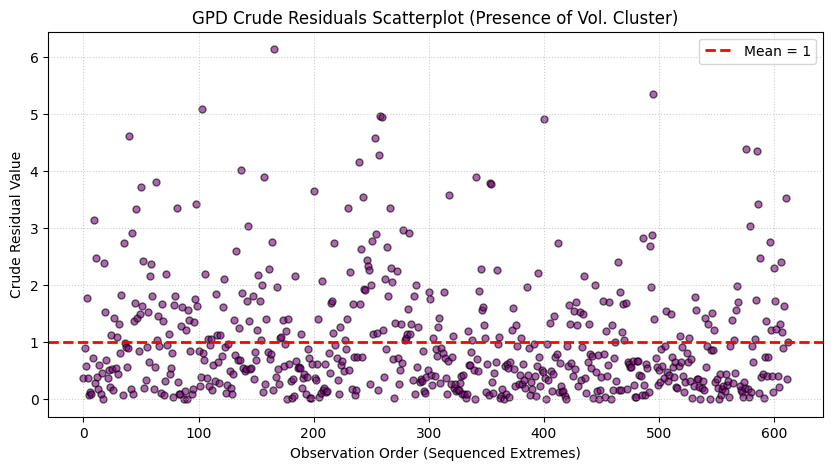

In [30]:
# 1. Calculate GPD crude residuals
# For GPD, if the model is correct, H(x) = 1 - (1 + xi*x/sigma)^(-1/xi)
# The crude residual is defined as -log(1 - H(x)), which simplifies to:
gpd_argument = 1 + (xi * exceedances / sigma)
gpd_argument = np.maximum(gpd_argument, 1e-10)

# If model is correct, these residuals must be i.i.d. Exponential(1)
gpd_residuals = (1 / xi) * np.log(gpd_argument)

# 2. Sequential Scatterplot of Residuals
plt.figure(figsize=(10, 5))
plt.scatter(range(len(gpd_residuals)), gpd_residuals, color='purple', alpha=0.6, edgecolors='k', s=25)

# Add a reference line at the mean of Exp(1), which is 1
plt.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Mean = 1')

plt.title('GPD Crude Residuals Scatterplot (Presence of Vol. Cluster)')
plt.xlabel('Observation Order (Sequenced Extremes)')
plt.ylabel('Crude Residual Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Volatility Check

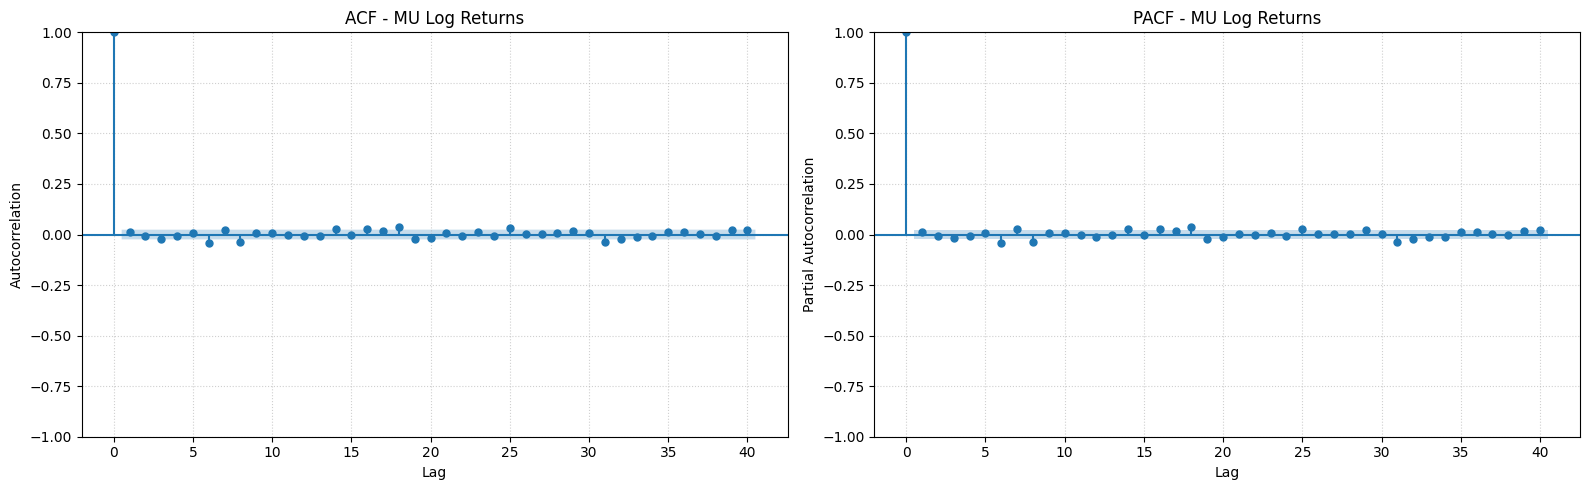

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF
plot_acf(returns, lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF - MU Log Returns')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')
axes[0].grid(True, linestyle=':', alpha=0.6)

# PACF
plot_pacf(returns, lags=40, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF - MU Log Returns')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Partial Autocorrelation')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

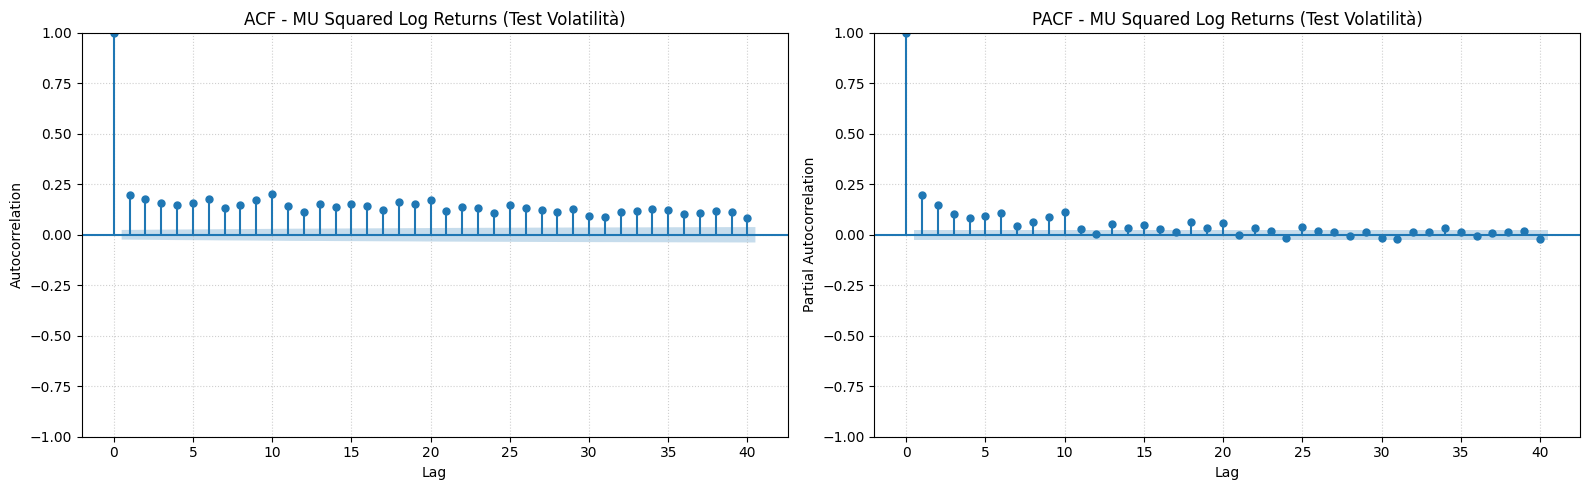

In [32]:
squared_returns = returns ** 2

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF squarred returns
plot_acf(squared_returns, lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF - MU Squared Log Returns (Test Volatilità)')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')
axes[0].grid(True, linestyle=':', alpha=0.6)

# PACF squarred returns
plot_pacf(squared_returns, lags=40, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF - MU Squared Log Returns (Test Volatilità)')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Partial Autocorrelation')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

GARCH(1,1)
$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

In [33]:
returns_scaled = returns * 100

In [34]:
# GARCH(1,1) NORMAL DIST
model_norm = arch_model(returns_scaled, mean='Constant', vol='Garch', p=1, q=1, dist='normal')
garch_fit_norm = model_norm.fit(disp='off')
print(garch_fit_norm.summary())

std_resid_norm = garch_fit_norm.resid / garch_fit_norm.conditional_volatility
std_resid_norm_squared = std_resid_norm ** 2

# Ljung-Box Test
lb_norm = acorr_ljungbox(std_resid_norm_squared, lags=[10, 15, 20], return_df=True)
print(lb_norm)


# GARCH(1,1) T-STUDENT DIST
model_t = arch_model(returns_scaled, mean='Constant', vol='Garch', p=1, q=1, dist='t')
garch_fit_t = model_t.fit(disp='off')

print(garch_fit_t.summary())

std_resid_t = garch_fit_t.resid / garch_fit_t.conditional_volatility
std_resid_t_squared = std_resid_t ** 2

# Ljung-Box Test for T-STUDENT DIST
lb_t = acorr_ljungbox(std_resid_t_squared, lags=[10, 15, 20], return_df=True)
print(lb_t)

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                     MU   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -17123.2
Distribution:                  Normal   AIC:                           34254.3
Method:            Maximum Likelihood   BIC:                           34281.6
                                        No. Observations:                 6654
Date:                Mon, Jun 22 2026   Df Residuals:                     6653
Time:                        05:27:49   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0865  3.562e-02      2.428  1.520e-02 [1.666e-0

In [35]:
returns_scaled = returns * 100

# Setup rolling parameters
rolling_window = 500
forecast_vol_norm = []
forecast_vol_t = []

# Loop
for i in range(rolling_window, len(returns_scaled)):
    train_data = returns_scaled.iloc[i - rolling_window:i]

    # Fit Normal GARCH(1,1)
    model_norm = arch_model(train_data, mean='Constant', vol='Garch', p=1, q=1, dist='normal')
    fitted_norm = model_norm.fit(disp='off')
    f_norm = fitted_norm.forecast(horizon=1)
    forecast_vol_norm.append(np.sqrt(f_norm.variance.values[-1, :][0]))

    # Fit Student's t GARCH(1,1)
    model_t = arch_model(train_data, mean='Constant', vol='Garch', p=1, q=1, dist='t')
    fitted_t = model_t.fit(disp='off')
    f_t = fitted_t.forecast(horizon=1)
    forecast_vol_t.append(np.sqrt(f_t.variance.values[-1, :][0]))

# 2. Align Forecasts with Dates
forecast_dates = returns_scaled.index[rolling_window:]
df_forecasts = pd.DataFrame({
    'GARCH_Normal': forecast_vol_norm,
    'GARCH_Student': forecast_vol_t
}, index=forecast_dates)

# Computing Realized Volatility Proxy (5-day rolling standard deviation)
df_forecasts['Realized_Vol_5d'] = returns_scaled.rolling(window=5).std().loc[forecast_dates]
df_forecasts = df_forecasts.dropna()

corr_norm = df_forecasts['GARCH_Normal'].corr(df_forecasts['Realized_Vol_5d'])
corr_t = df_forecasts['GARCH_Student'].corr(df_forecasts['Realized_Vol_5d'])

print(f"\nCorrelation [GARCH Normal vs Realized]: {corr_norm:.4f}")
print(f"Correlation [GARCH Student's t vs Realized]: {corr_t:.4f}")


Correlation [GARCH Normal vs Realized]: 0.6901
Correlation [GARCH Student's t vs Realized]: 0.7067


In [36]:
actual_realized = df_forecasts['Realized_Vol_5d']
pred_normal = df_forecasts['GARCH_Normal']
pred_student = df_forecasts['GARCH_Student']

def calculate_oos_metrics(forecast, actual):
    errors = forecast - actual

    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors ** 2))
    corr = np.corrcoef(forecast, actual)[0, 1]


    ss_res = np.sum(errors ** 2)
    ss_tot = np.sum((actual - np.mean(actual)) ** 2)
    r2_abs = 1 - (ss_res / ss_tot)

    mean_error = np.mean(errors)  # Bias indicator
    mape = np.mean(np.abs(errors / actual)) * 100

    return [mae, rmse, corr, r2_abs, mean_error, mape]


metrics_norm = calculate_oos_metrics(pred_normal, actual_realized)
metrics_student = calculate_oos_metrics(pred_student, actual_realized)

oos_metrics_table = pd.DataFrame(
    [metrics_norm, metrics_student],
    columns=['MAE', 'RMSE', 'Corr', 'R2_abs', 'Mean Error (Bias)', 'MAPE (%)'],
    index=['GARCH_Normal OOS vs Realized', 'GARCH_Student OOS vs Realized']
)

print(oos_metrics_table.round(4).to_string())

                                  MAE    RMSE    Corr  R2_abs  Mean Error (Bias)  MAPE (%)
GARCH_Normal OOS vs Realized   0.9627  1.2808  0.6901  0.4532             0.2614   48.7981
GARCH_Student OOS vs Realized  0.9475  1.2567  0.7067  0.4736             0.2760   47.9333


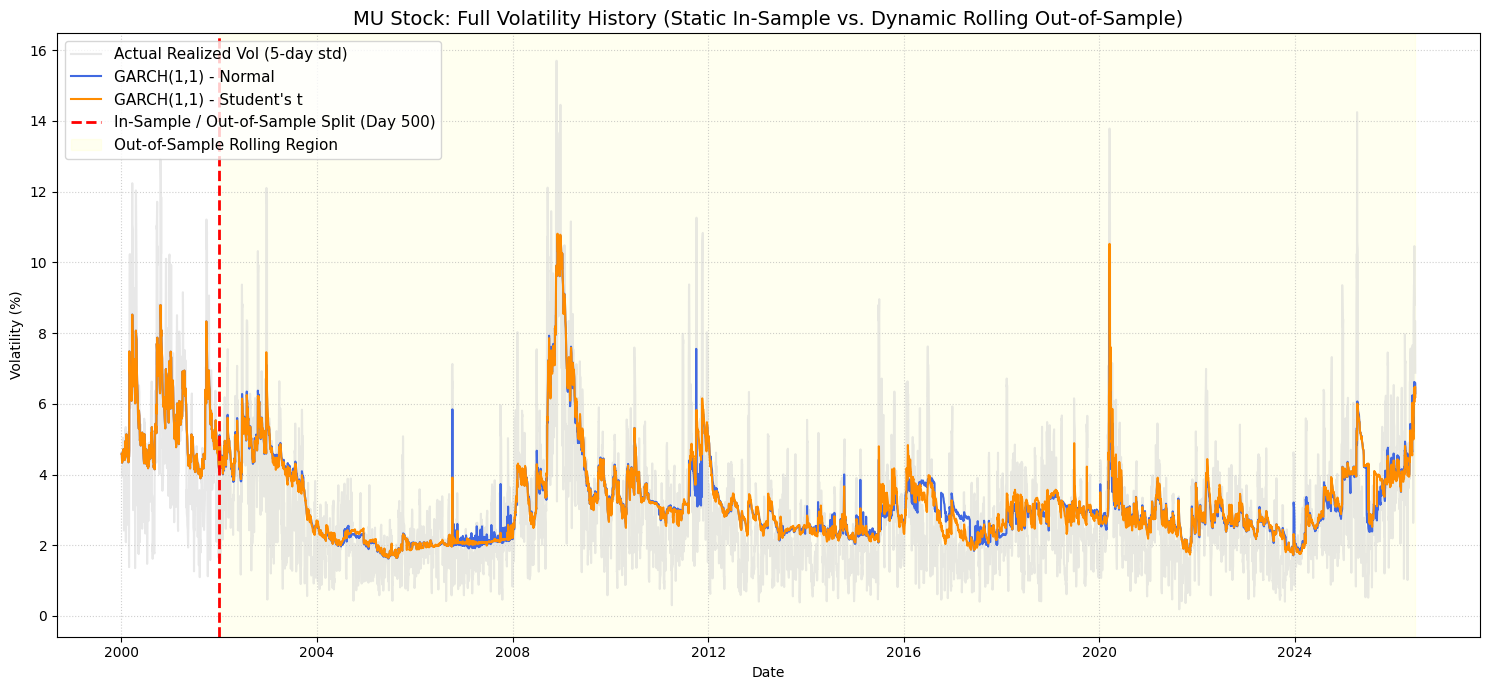

In [37]:
in_sample_data = returns_scaled.iloc[:rolling_window]
model_in_sample = arch_model(in_sample_data, mean='Constant', vol='Garch', p=1, q=1, dist='normal').fit(disp='off')
insample_vol = model_in_sample.conditional_volatility

full_vol_norm = pd.concat([insample_vol, df_forecasts['GARCH_Normal']])
full_vol_t = pd.concat([insample_vol, df_forecasts['GARCH_Student']])
full_realized = returns_scaled.rolling(window=5).std()

plt.figure(figsize=(15, 7))

plt.plot(full_realized.index, full_realized, color='lightgray', alpha=0.5, label='Actual Realized Vol (5-day std)')

plt.plot(full_vol_norm.index, full_vol_norm, color='royalblue', linewidth=1.5, label='GARCH(1,1) - Normal')
plt.plot(full_vol_t.index, full_vol_t, color='darkorange', linewidth=1.5, label="GARCH(1,1) - Student's t")

split_date = df_forecasts.index[0]
plt.axvline(x=split_date, color='red', linestyle='--', linewidth=2, label='In-Sample / Out-of-Sample Split (Day 500)')
plt.axvspan(split_date, full_vol_norm.index[-1], color='yellow', alpha=0.06, label='Out-of-Sample Rolling Region')

plt.title('MU Stock: Full Volatility History (Static In-Sample vs. Dynamic Rolling Out-of-Sample)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [38]:
# GJR-GARCH(1,1)
returns_scaled = returns * 100
gjr_model = arch_model(returns_scaled, mean='Constant', vol='GARCH', p=1, o=1, q=1, dist='normal')
gjr_fit = gjr_model.fit(disp='off')
print(gjr_fit.summary())

                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:                     MU   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -17108.7
Distribution:                  Normal   AIC:                           34227.3
Method:            Maximum Likelihood   BIC:                           34261.3
                                        No. Observations:                 6654
Date:                Mon, Jun 22 2026   Df Residuals:                     6653
Time:                        05:35:53   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0614  3.529e-02      1.741  8.170e-02 [-7.72

EWMA : $$\sigma_t^2 = \lambda \sigma_{t-1}^2 + (1 - \lambda) r_{t-1}^2$$

In [39]:
# EXTRACTION OF ALL VaR MODELS (HS 100, HS 500, HS 1000, EWMA)
losses = -returns
n_total = len(losses)
alpha_target = 0.05 # 5% VaR target

# Initialization of series
var_hs_100 = pd.Series(index=losses.index, dtype=float)
var_hs_500 = pd.Series(index=losses.index, dtype=float)
var_hs_1000 = pd.Series(index=losses.index, dtype=float)

# 1. Historical Simulation rolling windows
for t in range(100, n_total):
    var_hs_100.iloc[t] = losses.iloc[t-100:t].quantile(1 - alpha_target)

for t in range(500, n_total):
    var_hs_500.iloc[t] = losses.iloc[t-500:t].quantile(1 - alpha_target)

for t in range(1000, n_total):
    var_hs_1000.iloc[t] = losses.iloc[t-1000:t].quantile(1 - alpha_target)

# EWMA Parametric Volatility (RiskMetrics approach)
lam = 0.94
vols = np.zeros(n_total)
vols[0] = losses.iloc[0:30].var() # Seed variance

for t in range(1, n_total):
    vols[t] = lam * vols[t-1] + (1 - lam) * (losses.iloc[t-1]**2)

var_ewma = 1.645 * np.sqrt(vols)
var_ewma = pd.Series(var_ewma, index=losses.index)

# Truncate all series to start from day 1000 to ensure a fair comparison
eval_losses = losses.iloc[1000:]
var_models = {
    'HS 100': var_hs_100.iloc[1000:],
    'HS 500': var_hs_500.iloc[1000:],
    'HS 1000': var_hs_1000.iloc[1000:],
    'EWMA': var_ewma.iloc[1000:]
}

In [40]:
# KUPIEC / UNCONDITIONAL COVERAGE TEST
kupiec_results = {}

for name, var_series in var_models.items():
    hit = (eval_losses > var_series).astype(int).values
    N = len(hit)
    x = np.sum(hit)
    p_hat = x / N

    # Likelihood ratio formula for Kupiec
    lr_uc = -2 * ((N - x) * np.log(1 - alpha_target) + x * np.log(alpha_target) -
                  ((N - x) * np.log(1 - p_hat) + x * np.log(p_hat)))

    p_val_uc = 1 - stats.chi2.cdf(lr_uc, df=1)
    decision = "Reject H0 (Bad Coverage)" if lr_uc > 3.84 else "Accept H0 (Good Coverage)"

    print(f"[{name}] LR Stat: {lr_uc:.2f} | p-value: {p_val_uc:.4f} -> {decision}")

    kupiec_results[name] = {'LR_uc': lr_uc, 'p_val_uc': p_val_uc, 'hit': hit, 'X': x, 'N': N}

[HS 100] LR Stat: 16.18 | p-value: 0.0001 -> Reject H0 (Bad Coverage)
[HS 500] LR Stat: 4.22 | p-value: 0.0399 -> Reject H0 (Bad Coverage)
[HS 1000] LR Stat: 0.07 | p-value: 0.7935 -> Accept H0 (Good Coverage)
[EWMA] LR Stat: 0.61 | p-value: 0.4351 -> Accept H0 (Good Coverage)


In [41]:
# CHRISTOFFERSEN INDEPENDENCE TEST (Volatility Clustering Check)
christoffersen_results = {}

for name, data in kupiec_results.items():
    hit = data['hit']
    n00 = n01 = n10 = n11 = 0

    # Count transitions between consecutive days
    for i in range(1, len(hit)):
        if hit[i-1] == 0 and hit[i] == 0: n00 += 1
        elif hit[i-1] == 0 and hit[i] == 1: n01 += 1
        elif hit[i-1] == 1 and hit[i] == 0: n10 += 1
        elif hit[i-1] == 1 and hit[i] == 1: n11 += 1

    p01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
    p11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
    p_shared = (n01 + n11) / (n00 + n01 + n10 + n11)

    # Likelihood setup
    log_L_null = (n00 + n10) * np.log(1 - p_shared) + (n01 + n11) * np.log(p_shared)
    log_L_alt = n00 * np.log(1 - p01) + n01 * np.log(p01) + n10 * np.log(1 - p11) + n11 * np.log(p11)

    lr_ind = -2 * (log_L_null - log_L_alt)
    p_val_ind = 1 - stats.chi2.cdf(lr_ind, df=1)

    decision = "Reject H0 (Clustering Present)" if lr_ind > 3.84 else "Accept H0 (Independent Hits)"
    print(f"[{name}] LR Stat: {lr_ind:.2f} | p-value: {p_val_ind:.4f} -> {decision}")

    christoffersen_results[name] = {'LR_ind': lr_ind, 'p_val_ind': p_val_ind}

[HS 100] LR Stat: 9.01 | p-value: 0.0027 -> Reject H0 (Clustering Present)
[HS 500] LR Stat: 12.01 | p-value: 0.0005 -> Reject H0 (Clustering Present)
[HS 1000] LR Stat: 42.52 | p-value: 0.0000 -> Reject H0 (Clustering Present)
[EWMA] LR Stat: 0.10 | p-value: 0.7498 -> Accept H0 (Independent Hits)


[HS 100] Joint LR Stat: 25.19 | Joint p-value: 0.0000 -> Reject Model (Failed)
[HS 500] Joint LR Stat: 16.23 | Joint p-value: 0.0003 -> Reject Model (Failed)
[HS 1000] Joint LR Stat: 42.59 | Joint p-value: 0.0000 -> Reject Model (Failed)
[EWMA] Joint LR Stat: 0.71 | Joint p-value: 0.7008 -> Accept Model (Passed)


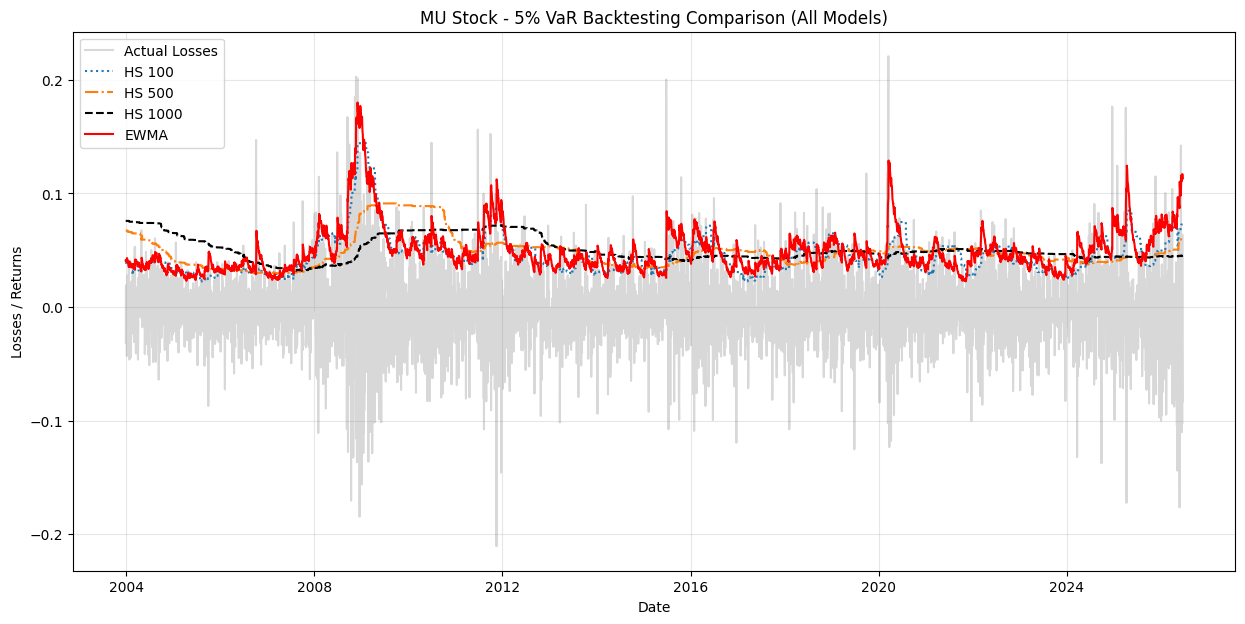

In [42]:
# JOINT CONDITIONAL COVERAGE TEST & GRAPHICAL ANALYSIS
for name in var_models.keys():
    lr_uc = kupiec_results[name]['LR_uc']
    lr_ind = christoffersen_results[name]['LR_ind']

    # Joint statistic is the sum of Unconditional and Independence statistics
    lr_cc = lr_uc + lr_ind
    p_val_cc = 1 - stats.chi2.cdf(lr_cc, df=2)

    decision = "Reject Model (Failed)" if lr_cc > 5.99 else "Accept Model (Passed)"
    print(f"[{name}] Joint LR Stat: {lr_cc:.2f} | Joint p-value: {p_val_cc:.4f} -> {decision}")

# Plotting everything for visual confirmation
plt.figure(figsize=(15, 7))
plt.plot(eval_losses.index, eval_losses, color='gray', alpha=0.3, label='Actual Losses')
plt.plot(var_models['HS 100'].index, var_models['HS 100'], label='HS 100', linestyle=':')
plt.plot(var_models['HS 500'].index, var_models['HS 500'], label='HS 500', linestyle='-.')
plt.plot(var_models['HS 1000'].index, var_models['HS 1000'], label='HS 1000', linestyle='--', color='black')
plt.plot(var_models['EWMA'].index, var_models['EWMA'], label='EWMA', color='red', linewidth=1.5)

plt.title("MU Stock - 5% VaR Backtesting Comparison (All Models)")
plt.xlabel("Date")
plt.ylabel("Losses / Returns")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

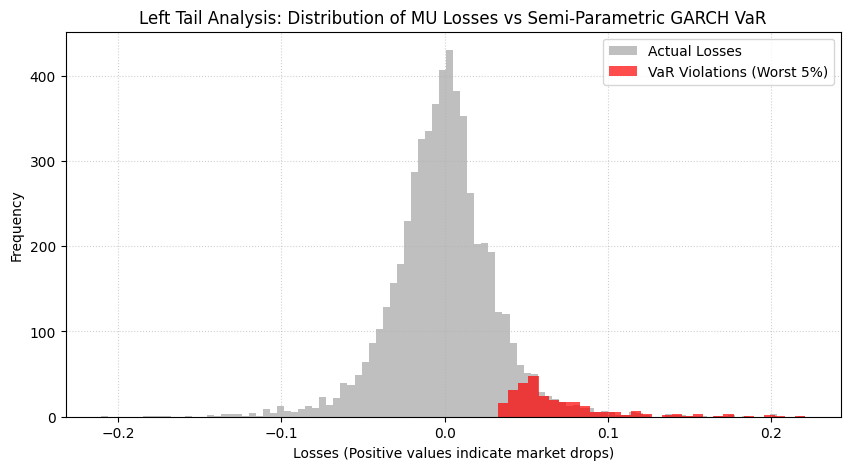

Empirical Standarized Residual Quantile (Loss Scale): 1.5542


In [43]:
# GARCH(1,1) SEMI-PARAMETRIC VaR
sigma_garch_scaled = garch_fit_norm.conditional_volatility
resid_std = garch_fit_norm.resid / sigma_garch_scaled
resid_std = resid_std.dropna()

alpha_target = 0.05
q_empirical_returns = np.quantile(resid_std, alpha_target)

q_empirical_losses = -q_empirical_returns
sigma_garch_unscaled = sigma_garch_scaled / 100

# Extract the constant mean from GARCH
mu_garch_losses = -(garch_fit_norm.params['mu'] / 100)

# Generate the Semi-Parametric GARCH VaR series
# VaR_t = mu + quantile * sigma_t
var_garch_semi = mu_garch_losses + (q_empirical_losses * sigma_garch_unscaled)

# Align the series for the out-of-sample backtest (from day 1000 onwards)
var_garch_semi_eval = var_garch_semi.iloc[1000:]
eval_losses = losses.iloc[1000:]

# TAIL VISUALIZATION
worst_5_losses = eval_losses[eval_losses > var_garch_semi_eval]

plt.figure(figsize=(10, 5))
plt.hist(eval_losses, bins=100, alpha=0.5, label='Actual Losses', color='gray')
plt.hist(worst_5_losses, bins=30, alpha=0.7, label='VaR Violations (Worst 5%)', color='red')

plt.title("Left Tail Analysis: Distribution of MU Losses vs Semi-Parametric GARCH VaR")
plt.xlabel("Losses (Positive values indicate market drops)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"Empirical Standarized Residual Quantile (Loss Scale): {q_empirical_losses:.4f}")

In [44]:
# RUNNING ALL BACKTESTS FOR EWMA VS GARCH SEMI-PARAMETRIC
def run_full_backtest(losses, var_series, alpha=0.05):
    hit = (losses > var_series).astype(int).values
    N = len(hit)
    x = np.sum(hit)
    p_hat = max(min(x / N, 1 - 1e-10), 1e-10)

    # Kupiec Test (Unconditional Coverage)
    lr_uc = -2 * ((N - x) * np.log(1 - alpha) + x * np.log(alpha) -
                  ((N - x) * np.log(1 - p_hat) + x * np.log(p_hat)))
    p_val_uc = 1 - stats.chi2.cdf(lr_uc, df=1)

    # Christoffersen Test (Independence)
    n00 = n01 = n10 = n11 = 0
    for i in range(1, len(hit)):
        if hit[i-1] == 0 and hit[i] == 0: n00 += 1
        elif hit[i-1] == 0 and hit[i] == 1: n01 += 1
        elif hit[i-1] == 1 and hit[i] == 0: n10 += 1
        elif hit[i-1] == 1 and hit[i] == 1: n11 += 1

    p01 = max(min(n01 / (n00 + n01) if (n00 + n01) > 0 else 0, 1 - 1e-10), 1e-10)
    p11 = max(min(n11 / (n10 + n11) if (n10 + n11) > 0 else 0, 1 - 1e-10), 1e-10)
    p_shared = max(min((n01 + n11) / (n00 + n01 + n10 + n11), 1 - 1e-10), 1e-10)

    log_L_null = (n00 + n10) * np.log(1 - p_shared) + (n01 + n11) * np.log(p_shared)
    log_L_alt = n00 * np.log(1 - p01) + n01 * np.log(p01) + n10 * np.log(1 - p11) + n11 * np.log(p11)
    lr_ind = -2 * (log_L_null - log_L_alt)
    p_val_ind = 1 - stats.chi2.cdf(lr_ind, df=1)

    # Likelihood Joint Test (Conditional Coverage)
    lr_cc = lr_uc + lr_ind
    p_val_cc = 1 - stats.chi2.cdf(lr_cc, df=2)

    # Regression F-Test (Professor's approach)
    eta = hit - alpha
    df_reg = pd.DataFrame({'eta': eta})
    df_reg['eta_lag'] = df_reg['eta'].shift(1)
    df_reg = df_reg.dropna()
    Y_reg = df_reg['eta']
    X_reg = sm.add_constant(df_reg['eta_lag'])
    model_ols = sm.OLS(Y_reg, X_reg).fit()
    p_val_f = model_ols.f_pvalue

    return {
        'Total Obs': N,
        'Exceptions': x,
        'Kupiec p-val': round(p_val_uc, 4),
        'Christ. p-val': round(p_val_ind, 4),
        'Joint LR p-val': round(p_val_cc, 4),
        'Reg. F p-val': round(p_val_f, 4)
    }

# Gather models for comparison
comparison_list = {
    'EWMA (Parametric)': var_models['EWMA'],
    'GARCH Semi-Parametric': var_garch_semi_eval
}

# Run and format the results
results_final = {}
for name, var_series in comparison_list.items():
    results_final[name] = run_full_backtest(eval_losses, var_series, alpha=0.05)

summary_df = pd.DataFrame(results_final).T

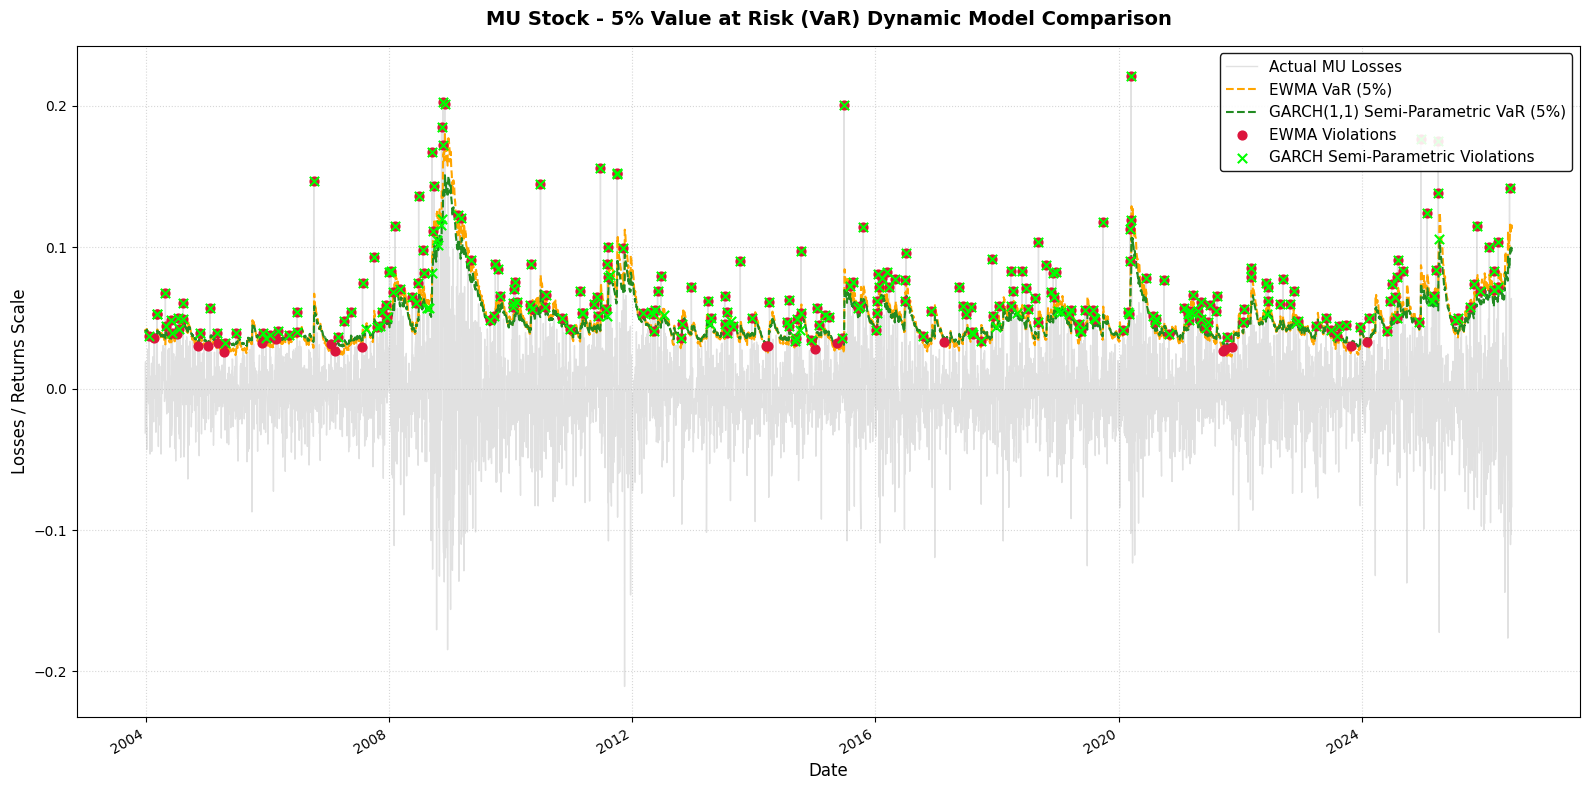

In [45]:
# DETAILED VISUALIZATION OF EWMA VS GARCH SEMI-PARAMETRIC WITH HITS

plt.figure(figsize=(16, 8))

plt.plot(eval_losses.index, eval_losses, color='darkgray', alpha=0.35, label='Actual MU Losses', linewidth=1)

plt.plot(var_models['EWMA'].index, var_models['EWMA'], color='orange', label='EWMA VaR (5%)',linestyle='--', linewidth=1.5)
plt.plot(var_garch_semi_eval.index, var_garch_semi_eval, color='forestgreen', label='GARCH(1,1) Semi-Parametric VaR (5%)', linestyle='--', linewidth=1.5)

ewma_hits = eval_losses[eval_losses > var_models['EWMA']]
garch_hits = eval_losses[eval_losses > var_garch_semi_eval]

plt.scatter(ewma_hits.index, ewma_hits, color='crimson', marker='o', s=40, zorder=5, label='EWMA Violations')
plt.scatter(garch_hits.index, garch_hits, color='lime', marker='x', s=45, zorder=5, label='GARCH Semi-Parametric Violations')

plt.title("MU Stock - 5% Value at Risk (VaR) Dynamic Model Comparison", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Losses / Returns Scale", fontsize=12)

plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right', fontsize=11, framealpha=0.9, edgecolor='inherit')

plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()